In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import importlib
import numpy as np
from engression.loss_func import energy_loss, energy_loss_two_sample
import torch
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
import torch, gc
import pickle
import matplotlib.pyplot as plt
import json
import cartopy.crs as ccrs



device: cpu


In [2]:
# LOAD ORIGINAL DATA

settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])

# set train/test split
ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)


torch.Size([128000, 1024])
torch.Size([64000, 1024])


In [3]:
ds_test

<xarray.Dataset> Size: 263MB
Dimensions:  (lat: 32, lon: 32, time: 64000)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 262MB ...

In [6]:
ds_test_masked = x_te[:, mask_x_te]
ds_test_masked.shape

torch.Size([64000, 648])

In [3]:
arr_restored = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ens_97_arr_raw.pt", map_location=torch.device('cpu'))
#arr_restored_proper = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ens_97_arr_restored.pt", map_location=torch.device('cpu'))




In [8]:
import numpy as np
from scipy.stats import chi2

def chi2_rankhist(counts):
    """
    Compute chi-square flatness test for a rank histogram.

    Parameters
    ----------
    counts : array-like, shape (B,)
        The bin counts of the rank histogram (B = ensemble size + 1).

    Returns
    -------
    chi2_stat : float
        Chi-square test statistic.
    p_value : float
        p-value against null hypothesis of uniformity.
    """
    counts = np.asarray(counts, dtype=float)
    N = counts.sum()               # total samples
    B = counts.size
    expected = N / B

    chi2_stat = np.sum((counts - expected) ** 2 / expected)
    df = B - 1
    p_value = 1 - chi2.cdf(chi2_stat, df)

    return chi2_stat, p_value

# ----------------------------------------------------
# Example usage
# ----------------------------------------------------
# Suppose you had an ensemble size of 10 ⇒ 11 rank bins
#hist = np.array([15, 9, 12, 11, 10, 13, 10, 12, 8, 10, 10])
#chi2_stat, pval = chi2_rankhist(hist)

#print("χ² statistic:", chi2_stat)
#print("p-value:", pval)

import numpy as np

def reliability_index(counts, normalize=True):
    """
    Compute Reliability Index (RI) for a rank histogram.

    Parameters
    ----------
    counts : array-like, shape (B,)
        Bin counts of the rank histogram.
    normalize : bool, default=True
        If True, scale RI into [0, 1].

    Returns
    -------
    RI : float
        Reliability Index (0 = flat, higher = less reliable).
    """
    counts = np.asarray(counts, dtype=float)
    N = counts.sum()
    B = counts.size
    if N == 0:
        return np.nan  # undefined if no counts
    
    freqs = counts / N
    RI_raw = np.abs(freqs - 1.0/B).sum()

    if normalize:
        RI = RI_raw / (2.0 * (1 - 1.0/B))
        return RI
    else:
        return RI_raw

# Example
#hist = np.array([15, 9, 12, 11, 10, 13, 10, 12, 8, 10, 10])
#print("RI (normalized):", reliability_index(hist))
#print("RI (raw):", reliability_index(hist, normalize=False))



In [7]:
n_members = arr_restored.shape[0]-1
print("n_members:", n_members)
chi2s = torch.zeros((648)) #np.zeros((648))
pvals = torch.zeros((648))
ri_vals = torch.zeros((648))

for n in range(648):
    # 2) compute ranks
    ranks = ut.rank_histogram(ds_test_masked[:,n].detach().numpy(), arr_restored[:-1,:,n].T.detach().numpy())
    
    # 3) plot histogram of ranks
    counts, bin_edges = np.histogram(
    ranks, 
    bins=np.arange(n_members + 2) - 0.5
    )
    #print("counts:", counts)

    # Chi^2
    chi2_stat, pval = chi2_rankhist(counts)

    # reliability index
    ri = reliability_index(counts)
    ri_vals[n] = ri
    
    print("Chi2:", chi2_stat)
    chi2s[n] = chi2_stat
    print(n)

# now compute measure ...

n_members: 97
Chi2: 1837.0094375
0
Chi2: 1158.8923125000001
1
Chi2: 656.216625
2
Chi2: 1162.24575
3
Chi2: 1988.6828125000002
4
Chi2: 3828.0295
5
Chi2: 4412.9241250000005
6
Chi2: 5283.1335
7
Chi2: 4183.9746875
8
Chi2: 3264.9092500000006
9
Chi2: 5105.165500000001
10
Chi2: 4045.0596875000006
11
Chi2: 5579.2251875
12
Chi2: 18729.8023125
13
Chi2: 8499.937562500001
14
Chi2: 2894.1231875
15
Chi2: 4916.5920625
16
Chi2: 2846.2073125
17
Chi2: 848.4375
18
Chi2: 599.4960625000001
19
Chi2: 459.38974999999994
20
Chi2: 2676.9551874999997
21
Chi2: 3964.1851875000007
22
Chi2: 2251.7362500000004
23
Chi2: 1066.2271875000001
24
Chi2: 1571.4814999999999
25
Chi2: 960.0227500000001
26
Chi2: 2837.617
27
Chi2: 26920.265624999996
28
Chi2: 39760.4981875
29
Chi2: 17566.8485625
30
Chi2: 27179.028499999997
31
Chi2: 26149.3149375
32
Chi2: 7512.682500000001
33
Chi2: 1072.569625
34
Chi2: 716.6183125
35
Chi2: 220.496375
36
Chi2: 222.20831249999998
37
Chi2: 269.32181249999996
38
Chi2: 374.0776875
39
Chi2: 284.4750625
40

Chi2spatial shape torch.Size([1, 1024])
53057.40625
143.25399780273438


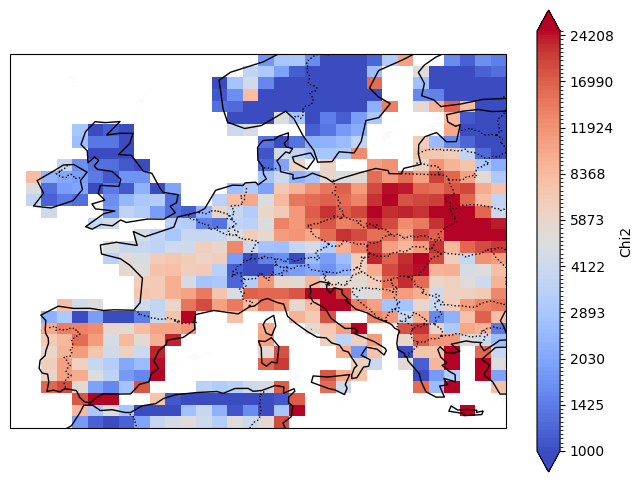

In [9]:
#############
### CHI^2 ###
#############

# restore nans
# add dimension for function ut.restore_nan_columns to work correctly
chi2_spatial_pre = ut.restore_nan_columns(chi2s[None, :], mask_x_te)
print("Chi2spatial shape", chi2_spatial_pre.shape)

# turn statistics array into xarray
chi2_spatial = ut.torch_to_dataarray(chi2_spatial_pre, ds, name="Chi2")
chi2_spatial

print(chi2_spatial.max().item())
print(chi2_spatial.min().item())

importlib.reload(ut)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ut.plot_temperature_panel(ax, chi2_spatial, chi2_spatial.max().item(), levels=np.logspace(np.log10(1000), np.log10(25000), 101), cbar=True)

97
RI max: 1.97979797979798
Chi2spatial shape torch.Size([1, 1024])
0.2577931582927704
0.017932990565896034


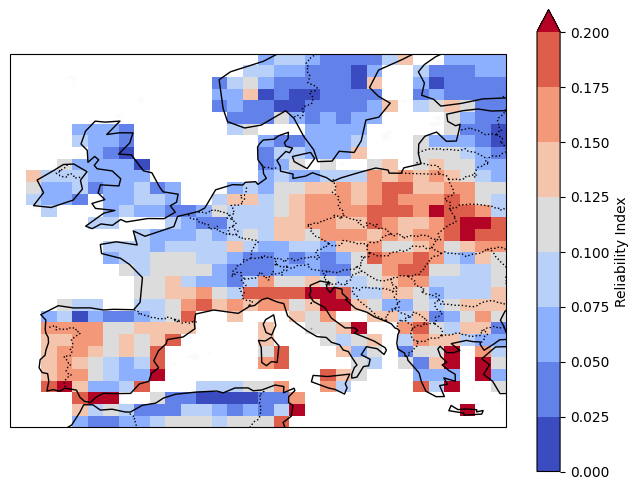

In [10]:
#########################
### Reliability Index ###
#########################

print(n_members)
bins=(np.arange(n_members + 2) - 0.5).shape[0]

ri_max_possible = 2*(1 - (1/bins))
print("RI max:", ri_max_possible)

# restore nans
# add dimension for function ut.restore_nan_columns to work correctly
ri_spatial_pre = ut.restore_nan_columns(ri_vals[None, :], mask_x_te)
print("Chi2spatial shape", ri_spatial_pre.shape)

# turn statistics array into xarray
ri_spatial = ut.torch_to_dataarray(ri_spatial_pre, ds, name="Reliability Index")
ri_spatial

print(ri_spatial.max().item())
print(ri_spatial.min().item())

importlib.reload(ut)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ut.plot_temperature_panel(ax, ri_spatial, chi2_spatial.max().item(), levels = np.linspace(0, 0.2, 9), cbar=True)

In [11]:
############
### R ^2 ###
############

m0_arr_restored = arr_restored.mean(dim=0)
m0_arr_restored.shape

def r2_score(y_true, y_pred, dim=0):
    """
    Compute R² per feature along `dim`.
    y_true, y_pred: torch tensors of same shape
    """
    ss_res = torch.sum((y_true - y_pred) ** 2, dim=dim)
    ss_tot = torch.sum((y_true - y_true.mean(dim=dim, keepdim=True)) ** 2, dim=dim)
    r2 = 1 - ss_res / ss_tot
    return r2

r2 = r2_score(x_te_reduced, m0_arr_restored, dim=0)
r2.shape

torch.Size([648])

Chi2spatial shape torch.Size([1, 1024])
0.9280404448509216
0.5467530488967896


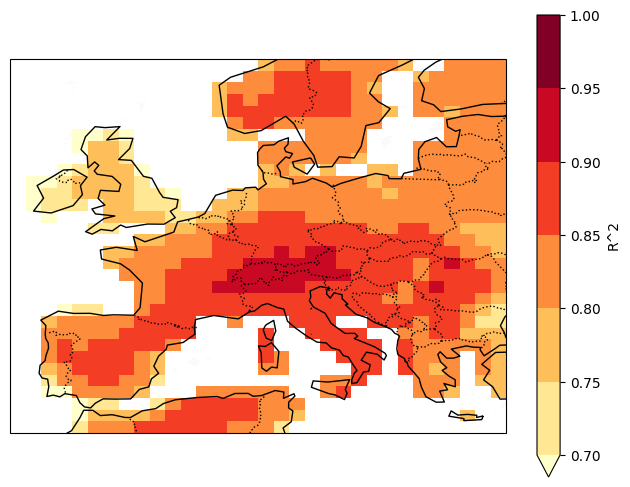

In [12]:
importlib.reload(ut)
# restore nans
# add dimension for function ut.restore_nan_columns to work correctly
r2_spatial_pre = ut.restore_nan_columns(r2[None, :], mask_x_te)
print("Chi2spatial shape", r2_spatial_pre.shape)

# turn statistics array into xarray
r2_spatial = ut.torch_to_dataarray(r2_spatial_pre, ds, name="R^2")
r2_spatial

print(r2_spatial.max().item())
print(r2_spatial.min().item())

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ut.plot_temperature_panel(ax, r2_spatial, r2_spatial.max().item(), levels = np.linspace(0.7, 1, 7), cbar=True, cmap="YlOrRd")


# compute mean R2 ???

In [13]:
def pearsonr_cols(x, y, dim=0, eps=1e-12):
    """
    Pearson correlation per feature along `dim` (default: samples axis).
    x, y: tensors of the same shape, e.g. (n_samples, n_features)
    Returns: tensor of shape equal to the non-reduced dims (e.g. (n_features,))
    """
    # center
    x_mean = x.mean(dim=dim, keepdim=True)
    y_mean = y.mean(dim=dim, keepdim=True)
    x_c = x - x_mean
    y_c = y - y_mean

    # numerator: covariance (without / (n-1) since it cancels in correlation)
    num = (x_c * y_c).sum(dim=dim)

    # denominator: product of std devs
    x_ss = (x_c * x_c).sum(dim=dim)
    y_ss = (y_c * y_c).sum(dim=dim)
    den = (x_ss * y_ss).sqrt().clamp_min(eps)

    return num / den


r_cols shape: torch.Size([648])
Chi2spatial shape torch.Size([1, 1024])
0.964705228805542
0.7588338851928711


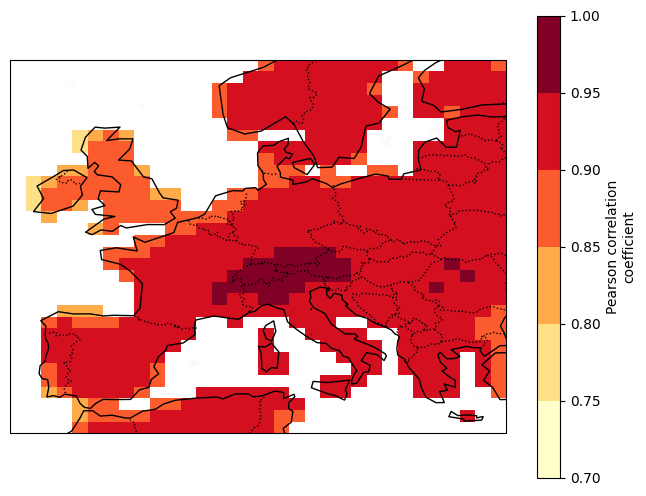

In [14]:
importlib.reload(ut)

r_cols = pearsonr_cols(x_te_reduced, m0_arr_restored, dim=0)  # shape: (648,)
print("r_cols shape:", r_cols.shape)

# restore nans
# add dimension for function ut.restore_nan_columns to work correctly
corr_spatial_pre = ut.restore_nan_columns(r_cols[None, :], mask_x_te)
print("Chi2spatial shape", corr_spatial_pre.shape)

# turn statistics array into xarray
corr_spatial = ut.torch_to_dataarray(corr_spatial_pre, ds, name="Pearson correlation coefficient")
corr_spatial

print(corr_spatial.max().item())
print(corr_spatial.min().item())

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ut.plot_temperature_panel(ax, corr_spatial, corr_spatial.max().item(), levels = np.linspace(0.7, 1, 7), cbar=True, cmap="YlOrRd")

In [13]:
####################
### Energy Score ###
####################

In [15]:
###################
### Time Series ###
###################

# mean of DPA ensemble
m0_arr_restored = arr_restored.mean(dim=0)

# Standard deviation along dim=0
std0 = arr_restored.std(dim=0)

# Minimum along dim=0
min0, _ = arr_restored.min(dim=0)

# Maximum along dim=0
max0, _ = arr_restored.max(dim=0)

torch.Size([64000, 648])


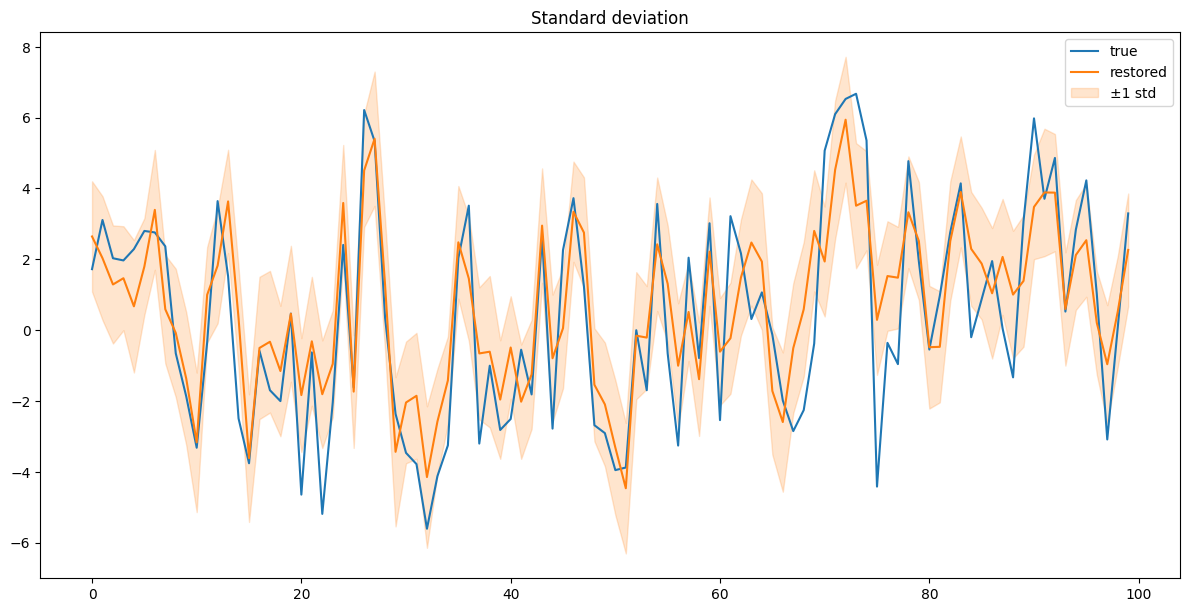

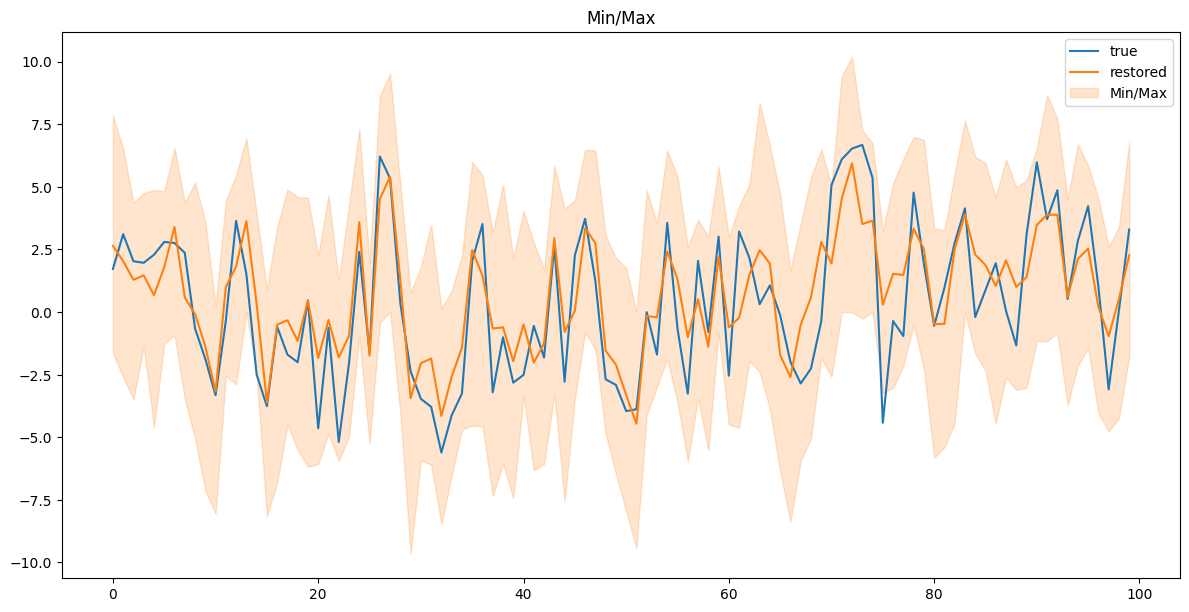

In [16]:
import matplotlib.pyplot as plt

print(std0.shape)


plt.figure(figsize=(12, 6))   # wider (12 inches) and not too tall (4 inches)

plt.plot(range(100), x_te_reduced[:100, 0], label="true")
plt.plot(range(100), m0_arr_restored.detach().numpy()[:100, 0], label="restored")
plt.fill_between(range(100), m0_arr_restored.detach().numpy()[:100, 0] - 1*std0.detach().numpy()[:100, 0], 
                 m0_arr_restored.detach().numpy()[:100, 0] + 1*std0.detach().numpy()[:100, 0],
                 color="tab:orange", alpha=0.2, label="±1 std")

plt.legend()
plt.tight_layout()
plt.title("Standard deviation")
plt.show()

########################################################################################################

plt.figure(figsize=(12, 6))
plt.plot(range(100), x_te_reduced[:100, 0], label="true")
plt.plot(range(100), m0_arr_restored.detach().numpy()[:100, 0], label="restored")
plt.fill_between(range(100), 
                 min0.detach().numpy()[:100, 0], 
                 max0.detach().numpy()[:100, 0],
                 color="tab:orange", alpha=0.2, label="Min/Max")

plt.legend()
plt.tight_layout()
plt.title("Min/Max")
plt.show()

In [17]:
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# true temperature - germany spatial average
temp_true_pre = ds_test.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_true_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_pre['lat']}, dims=['lat'])

temp_true = temp_true_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
temp_true

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 64000)
Coordinates:
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (time) float64 512kB 1.828 1.898 2.78 2.46 ... 7.901 7.755 9.183

In [18]:
# True Temperature
temp_true.TREFHT.isel(time=slice(100,150))

<xarray.DataArray 'TREFHT' (time: 50)> Size: 400B
array([ 1.37321541,  5.44734245,  2.94405465, -2.7758574 ,  0.27522747,
        2.97931148,  6.91692687,  5.38017396,  2.44414294,  2.09509509,
        4.09889635,  1.65469611,  1.99308389,  0.94577727,  1.24088649,
        1.63949798, -1.79629018, -0.03214496, -2.31998055, -1.74792829,
       -0.36703039,  3.38177523, -4.44806167, -4.41064028,  0.22506974,
        1.01688106,  1.07211497, -0.64111378,  3.09696975,  1.75275567,
       -1.35744629,  0.52356446,  3.73998398,  2.20620655,  4.05855496,
        2.55458344,  4.24905753,  6.7401572 ,  2.73948413,  3.9406026 ,
        3.16414923,  0.70945471,  4.39073741,  2.55908332, -2.0308962 ,
       -2.05555262,  0.73358541, -1.79328379, -2.17130435,  0.28558759])
Coordinates:
  * time     (time) object 400B 2000-08-21 00:00:00 ... 2003-07-12 00:00:00

In [19]:
# DPA Distribution
# create xarray for mean of DPA prediction
arr_nan = ut.restore_nan_columns(m0_arr_restored, mask_x_te)
dpa_mean_xr = (ut.torch_to_dataarray(arr_nan, ds_test, name="T_mean")).assign_coords(time=temp_true.time)
dpa_mean_xr.isel(time=slice(100,150))

# create xarray for std of DPA prediction
arr_std0 = ut.restore_nan_columns(std0, mask_x_te)
dpa_std0_xr = (ut.torch_to_dataarray(arr_std0, ds_test, name="T_std")).assign_coords(time=temp_true.time)

# calculate germany mean
# true temperature - germany spatial average
temp_dpa_pre = dpa_mean_xr.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
temp_dpa_std0_pre = dpa_std0_xr.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))

# create weights
# 1) define weights as above
weights_ger = np.cos(np.deg2rad(temp_dpa_pre['lat']))

# 2) wrap in a DataArray so xarray knows which dim it belongs to
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_pre['lat']}, dims=['lat'])

mean_temp_dpa = temp_dpa_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
mean_std0_temp_dpa = temp_dpa_std0_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
mean_std0_temp_dpa

<xarray.DataArray 'T_std' (time: 64000)> Size: 512kB
array([1.04509113, 0.94847315, 0.82027403, ..., 1.40111091, 1.47038634,
       1.51705978], shape=(64000,))
Coordinates:
  * time     (time) object 512kB 1995-07-27 00:00:00 ... 2100-08-31 00:00:00

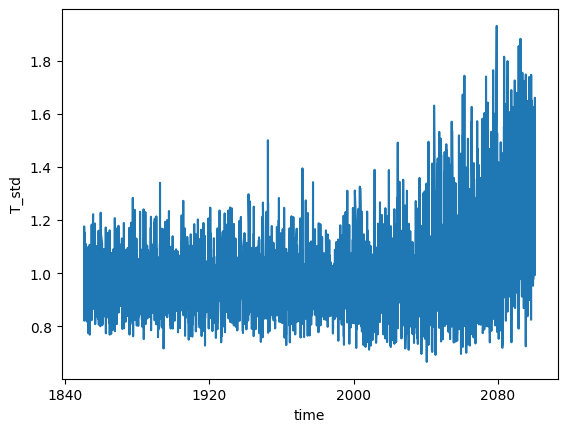

In [24]:
# plot temperature variability (standard deviation) over time
mean_std0_temp_dpa.isel(time=slice(-4769, 64000)).plot()

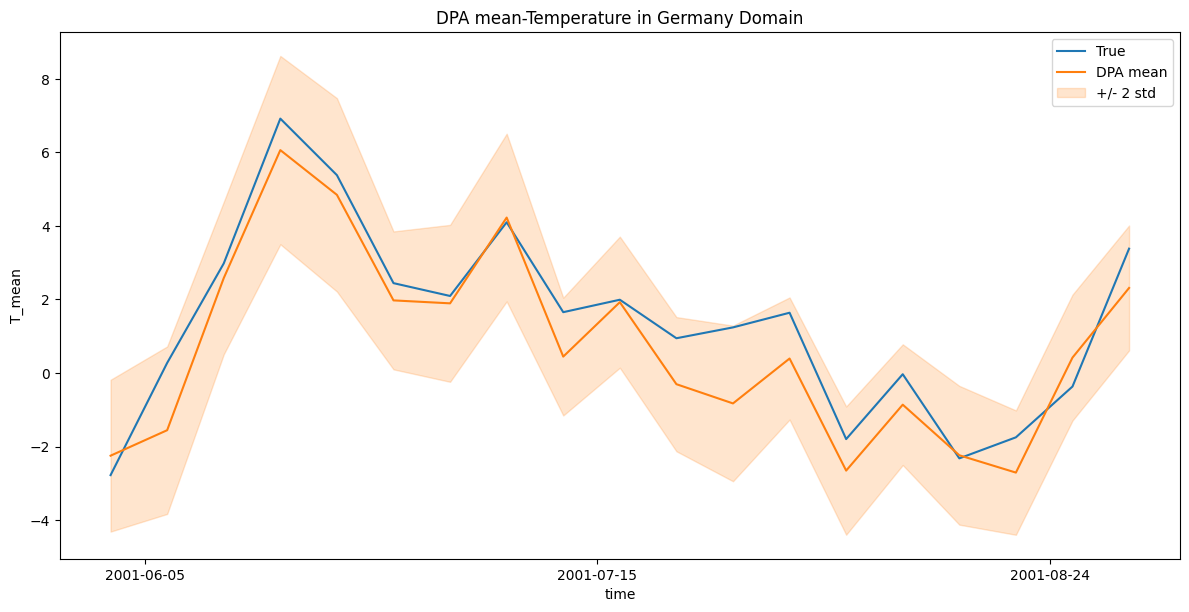

In [21]:
# Dummy dataset: daily values for 100 days
n_stds = 2
lower_env = mean_temp_dpa + n_stds * mean_std0_temp_dpa 
upper_env = mean_temp_dpa - n_stds * mean_std0_temp_dpa

plt.figure(figsize=(12, 6))

temp_true.TREFHT.isel(time=slice(103,122)).plot(label="True")
mean_temp_dpa.isel(time=slice(103,122)).plot(label="DPA mean")


# fill_between needs numpy arrays + axis
plt.fill_between(
    temp_true.isel(time=slice(103,122)).time.values,   # x-axis values (datetime64)
    lower_env.isel(time=slice(103,122)).values,        # lower bound
    upper_env.isel(time=slice(103,122)).values,        # upper bound
    color="tab:orange", alpha=0.2, label=f"+/- {n_stds} std"
)

plt.legend()
plt.tight_layout()
plt.title("DPA mean-Temperature in Germany Domain")
plt.show()

#################################################



#temp_true.TREFHT.isel(time=slice(123,141)).plot()
#mean_temp_dpa.isel(time=slice(123,141)).plot()
#plt.show()
#dpa_std0_xr

In [96]:
####################
### Energy Score ###
####################

# load energy score
e_loss = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ens_97_energy_loss_map.pt", map_location=torch.device('cpu'))
e_loss.shape

# load DPA predicted temperatures
#predicts_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/"
#dpa_t_samples_raw, dpa_t_samples, _, _ = ut.load_dpa_predicts(predicts_path, mask_x_te)

torch.Size([3, 648])

In [15]:
print(e_loss[:,0])

tensor([0.9448, 1.8873, 1.8851], grad_fn=<SelectBackward0>)


In [97]:
# turn e_loss array into xarray
e_loss_spatial_pre = ut.restore_nan_columns(e_loss[None, 0, :], mask_x_te)
e_loss_spatial_pre.shape
e_loss_spatial = ut.torch_to_dataarray(e_loss_spatial_pre, ds, name="Energy Loss")
e_loss_spatial

<xarray.DataArray 'Energy Loss' (lat: 32, lon: 32, time: 1)> Size: 4kB
array([[[       nan],
        [       nan],
        [       nan],
        ...,
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [0.54885054],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
...
        ...,
        [0.7549241 ],
        [0.78252256],
        [0.80804795]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [0.77329344],
        [0.8025851 ],
        [0.8402335 ]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [0.80398595],
        [0.83294237],
        [0.87869537]]], shape=(32, 32, 1), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 8B 0

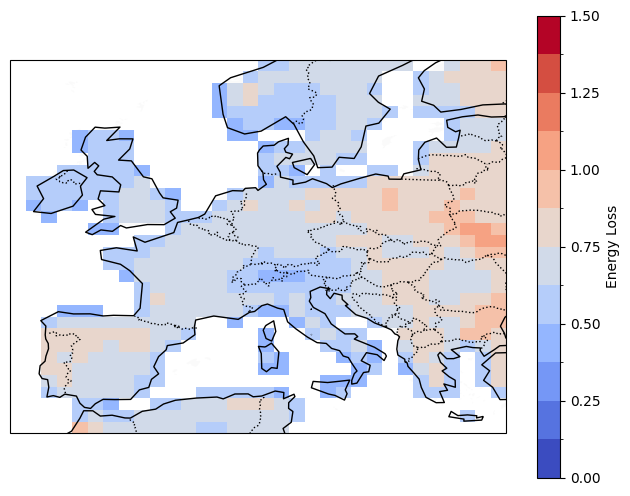

In [98]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ut.plot_temperature_panel(ax, e_loss_spatial, vmax_shared = 5, levels = np.linspace(0, 1.5, 13), cbar=True)

# Min/Max Temperatures

(97, 64000, 32, 32)


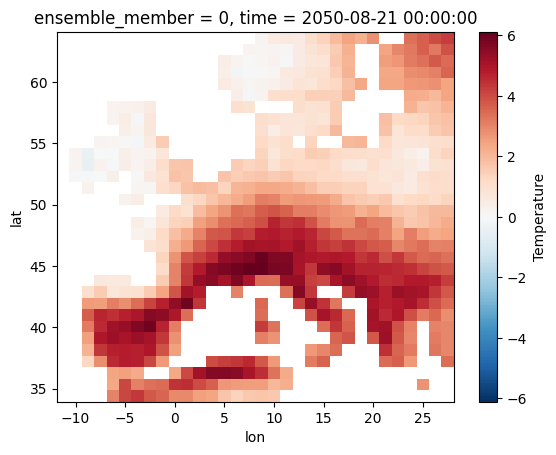

In [6]:
# turn DPA ensemble into xarray
arr = arr_restored_proper[1:,:,:].detach().numpy()

# Define coordinates
ensemble_coords = np.arange(arr.shape[0])         # 0..9
time_coords = ds_test.time
lats = ds_test.lat
lons = ds_test.lon
#feature_coords = [f"feat{i}" for i in range(arr.shape[2])]

lat_dim = 32
lon_dim = 32

# reshape
time_steps = arr.shape[1]
data_np = arr.reshape(ensemble_coords.shape[0], time_steps, lat_dim, lon_dim)
print(data_np.shape)

# Create DataArray
dpa_ens_xr = xr.DataArray(
    data_np,
    dims=("ensemble_member", "time", "lat", "lon"),
    coords={
        "ensemble_member": ensemble_coords,
        "time": time_coords,
        "lat": lats,
        "lon": lons
    },
    name="Temperature"
)

dpa_ens_xr.isel(ensemble_member = 0, time = 1050).plot()
#plt.imshow(data_np[0,0,:,:])
#data_np

In [7]:
# 250*19 = 4.750 


# choose one ensemble member, LE member 100
## Truth
test_100 = ds_test.TREFHT.isel(time=slice(-4769, 64000))

## DPA ensemble
dpa_ensmemb100 = dpa_ens_xr.isel(time=slice(-4769, 64000))

## DPA ensemble mean
dpa_mean_ens_member100 = dpa_ens_xr.isel(time=slice(-4769, 64000)).mean(dim="ensemble_member")
dpa_mean_ens_member100

# prepare DPA ensemble in same way

<xarray.DataArray 'Temperature' (time: 4769, lat: 32, lon: 32)> Size: 20MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -0.1435712 ,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,  5.118773  ,
          5.2775216 ,  5.205784  ],
        [        nan,         nan,         nan, ...,  5.3315306 ,
          5.254074  ,  5.108861  ],
        [        nan,         nan,         nan, ...,  5.135588  ,
          5.300712  ,  5.1857204 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ..., -0.17078276,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ..., 11.683785  ,
         12.109879  , 12.180786  ],
        [        nan,         nan,         nan, ..., 11.876728  ,
         11.86415   , 11.717861  ],
        [        nan,         nan,         nan, ..., 11.392858  ,
         11.790666  , 11.906344  ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  5.316758  ,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ..., 13.184499  ,
         13.579711  , 13.868125  ],
        [        nan,         nan,         nan, ..., 13.260329  ,
         13.354764  , 13.453255  ],
        [        nan,         nan,         nan, ..., 12.686979  ,
         13.1985855 , 13.495457  ]]], shape=(4769, 32, 32), dtype=float32)
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5

In [8]:
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# calculate germany mean value
## Truth
temp_true_pre_100 = test_100.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
weights_ger = np.cos(np.deg2rad(temp_true_pre_100['lat']))
w_da_ger = xr.DataArray(weights_ger, coords={'lat': temp_true_pre_100['lat']}, dims=['lat'])
temp_true_ger = temp_true_pre_100.weighted(w_da_ger).mean(dim=('lat', 'lon'))

## DPA ensemble
temp_dpa_ens_100_ger_pre = dpa_ensmemb100.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
temp_dpa_ens_100_ger = temp_dpa_ens_100_ger_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))

## DPA ensemblese mean
ger_dpa_mean_ensmemb100_pre = dpa_mean_ens_member100.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
weights_ger = np.cos(np.deg2rad(ger_dpa_mean_ensmemb100_pre['lat']))
w_da_ger = xr.DataArray(weights_ger, coords={'lat': ger_dpa_mean_ensmemb100_pre['lat']}, dims=['lat'])
ger_dpa_mean_ensmemb100 = ger_dpa_mean_ensmemb100_pre.weighted(w_da_ger).mean(dim=('lat', 'lon'))
ger_dpa_mean_ensmemb100

<xarray.DataArray 'Temperature' (time: 4769)> Size: 38kB
array([0.66136243, 1.61304616, 1.92028497, ..., 7.48208744, 8.90897417,
       8.73470301], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

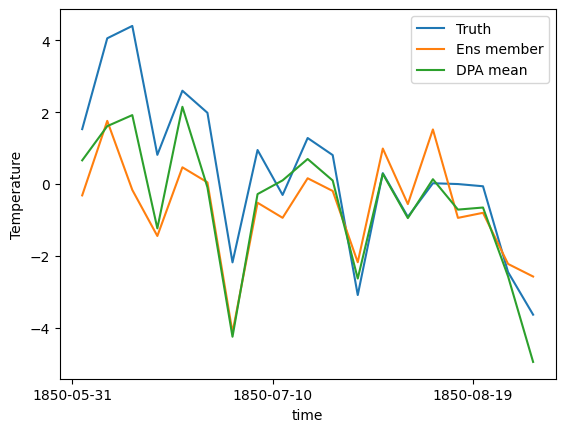

In [9]:
temp_true_ger.isel(time=slice(0,19)).plot(label="Truth")
temp_dpa_ens_100_ger.isel(ensemble_member=0, time=slice(0,19)).plot(label="Ens member")
ger_dpa_mean_ensmemb100.isel(time=slice(0,19)).plot(label="DPA mean")
plt.legend()

In [10]:
import pandas as pd


#ensmemb100_grouped = ger_mean_ensmemb100.groupby("time.year")#.idxmax()
truth_grouped = temp_true_ger.groupby("time.year")

max_times = []
min_times = []

# extract indices of max/min temperatures per year from one test member (ensemble member 100)
for key, group in truth_grouped:
    print("Year:", key)
    max_date = group.idxmax(dim="time")
    #print("group:", max_date.values)
    min_date = group.idxmin(dim="time")
    #print("group:", min_date.values)
    max_times.append((str(max_date.values)))
    min_times.append((str(min_date.values)))

max_times
temp_true_ger

Year: 1850
Year: 1851
Year: 1852
Year: 1853
Year: 1854
Year: 1855
Year: 1856
Year: 1857
Year: 1858
Year: 1859
Year: 1860
Year: 1861
Year: 1862
Year: 1863
Year: 1864
Year: 1865
Year: 1866
Year: 1867
Year: 1868
Year: 1869
Year: 1870
Year: 1871
Year: 1872
Year: 1873
Year: 1874
Year: 1875
Year: 1876
Year: 1877
Year: 1878
Year: 1879
Year: 1880
Year: 1881
Year: 1882
Year: 1883
Year: 1884
Year: 1885
Year: 1886
Year: 1887
Year: 1888
Year: 1889
Year: 1890
Year: 1891
Year: 1892
Year: 1893
Year: 1894
Year: 1895
Year: 1896
Year: 1897
Year: 1898
Year: 1899
Year: 1900
Year: 1901
Year: 1902
Year: 1903
Year: 1904
Year: 1905
Year: 1906
Year: 1907
Year: 1908
Year: 1909
Year: 1910
Year: 1911
Year: 1912
Year: 1913
Year: 1914
Year: 1915
Year: 1916
Year: 1917
Year: 1918
Year: 1919
Year: 1920
Year: 1921
Year: 1922
Year: 1923
Year: 1924
Year: 1925
Year: 1926
Year: 1927
Year: 1928
Year: 1929
Year: 1930
Year: 1931
Year: 1932
Year: 1933
Year: 1934
Year: 1935
Year: 1936
Year: 1937
Year: 1938
Year: 1939
Year: 1940

<xarray.DataArray 'TREFHT' (time: 4769)> Size: 38kB
array([1.530063  , 4.05761067, 4.4016487 , ..., 7.90116246, 7.75461501,
       9.18294173], shape=(4769,))
Coordinates:
  * time     (time) object 38kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

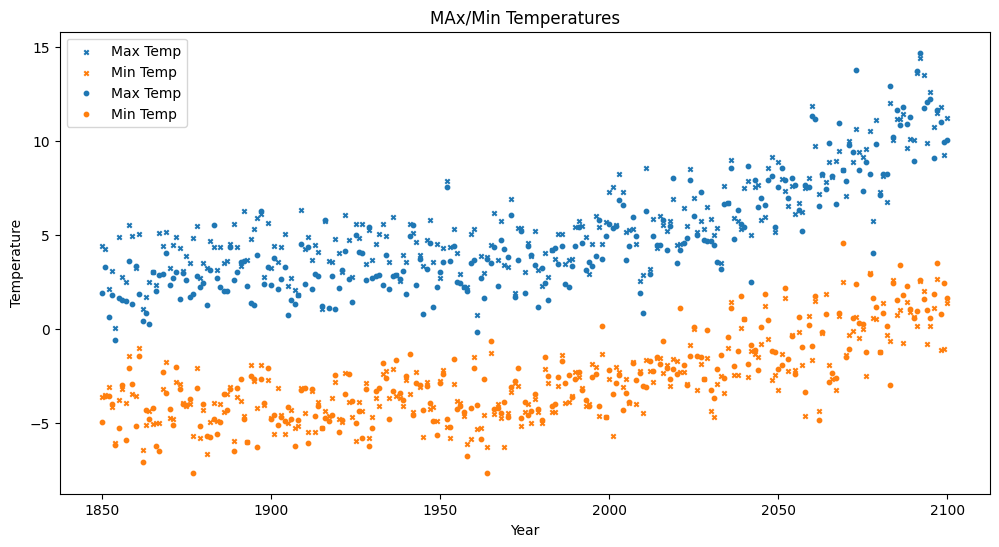

In [56]:
#max_times
#temp_true_ger.sel(time='1850-06-12')

# extract temperatures corresponding to max/min in test member from DPA ensemble (= distribution) and from DPA ensemble mean

list_temp_true_max = []
list_temp_true_min = []

list_dpa_ens_max = []
list_dpa_ens_min = []

list_dpa_mean_max = []
list_dpa_mean_min = []

years = np.arange(1850, 2101, 1)

for i in range(251):
    #print(i)

    # true (test) temperature
    list_temp_true_max.append(temp_true_ger.sel(time=max_times[i]))
    list_temp_true_min.append(temp_true_ger.sel(time=min_times[i]))

    # DPA ensemble
    list_dpa_ens_max.append(temp_dpa_ens_100_ger.sel(time=max_times[i]).values[:,0])
    list_dpa_ens_min.append(temp_dpa_ens_100_ger.sel(time=min_times[i]).values[:,0])
    #print(temp_dpa_ens_100_ger.sel(time=max_times[i]).values[:,0].shape)

    # DPA mean
    list_dpa_mean_max.append(ger_dpa_mean_ensmemb100.sel(time=max_times[i]))
    list_dpa_mean_min.append(ger_dpa_mean_ensmemb100.sel(time=min_times[i]))


# plot 
plt.figure(figsize=(12, 6))  # width=12, height=6 (inches)

plt.scatter(years, list_temp_true_max, label="Max Temp", marker='x', s = 10)
plt.scatter(years, list_temp_true_min, label="Min Temp", marker='x', s = 10)

plt.scatter(years, list_dpa_mean_max, label="Max Temp", color = "tab:blue", marker='o', s = 10)
plt.scatter(years, list_dpa_mean_min, label="Min Temp", color = "tab:orange", marker='o', s = 10)

plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("MAx/Min Temperatures")
plt.legend()
plt.show()

#max_times
#for arr in list_dpa_ens_max:
#plt.scatter(years, list_dpa_ens_max, alpha=0.6, s=10)
#plt.show()

## max/min value per year of test member 100
## all values of dpa 
#arr_restored_proper.shape

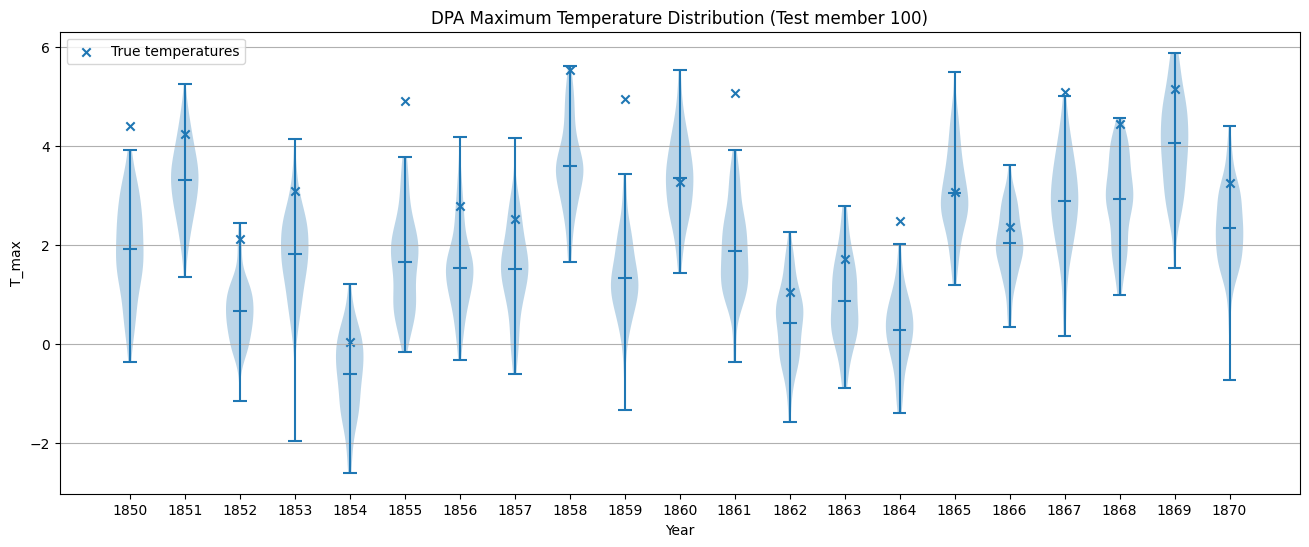

[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870]


In [82]:
no_violins = 21

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
# plot violin plot
axs.violinplot(
    list_dpa_ens_max[:no_violins],         # list of arrays, one array per year 
    showmeans=True,
    showmedians=False,
)
axs.scatter(range(1,no_violins+1), list_temp_true_max[:no_violins], label="True temperatures", marker="x")

axs.set_title('DPA Maximum Temperature Distribution (Test member 100)')


axs.yaxis.grid(True)

axs.set_xticks(range(1,252,1)[:no_violins])  
axs.set_xticklabels(years[:no_violins])

axs.set_xlabel('Year')
axs.set_ylabel('T_max')
plt.legend()
plt.show()

print(years[:no_violins])

0 21


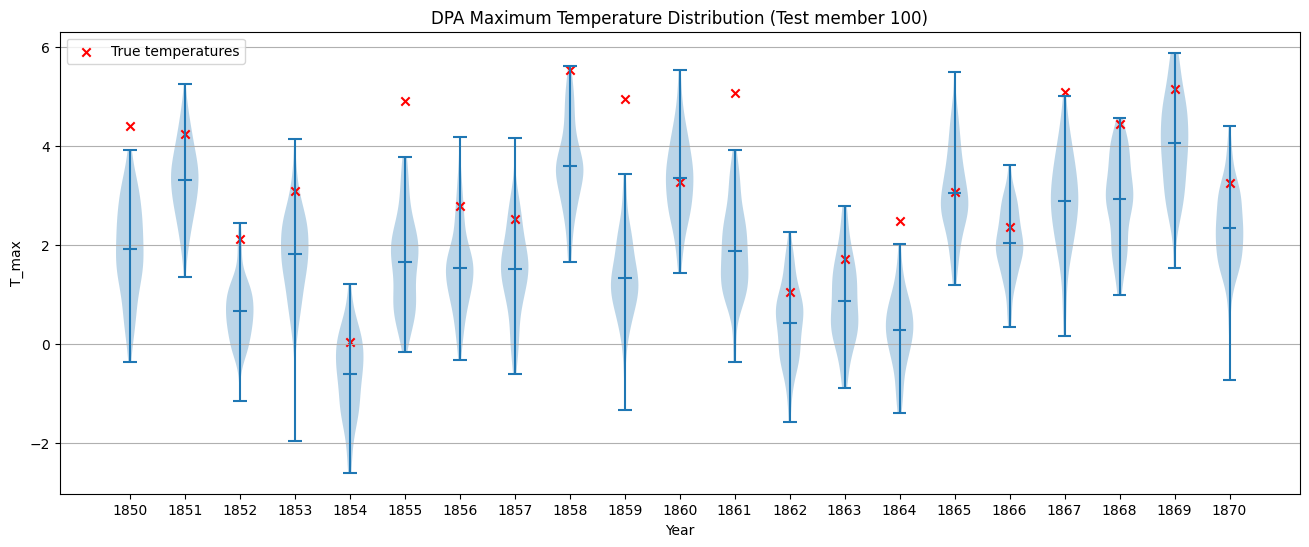

20 41


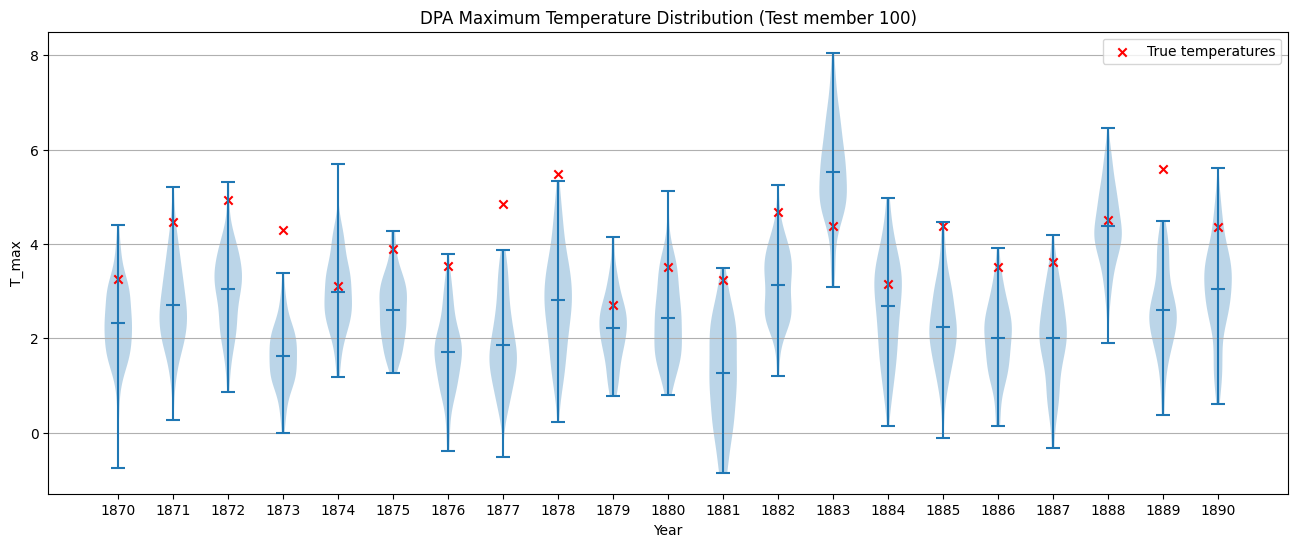

40 61


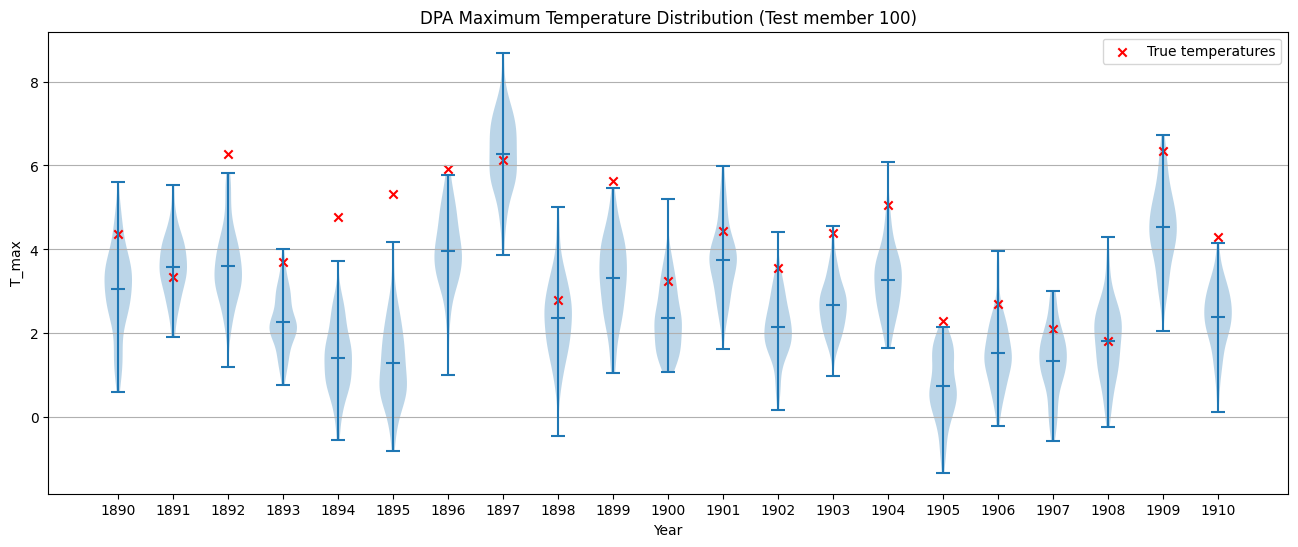

60 81


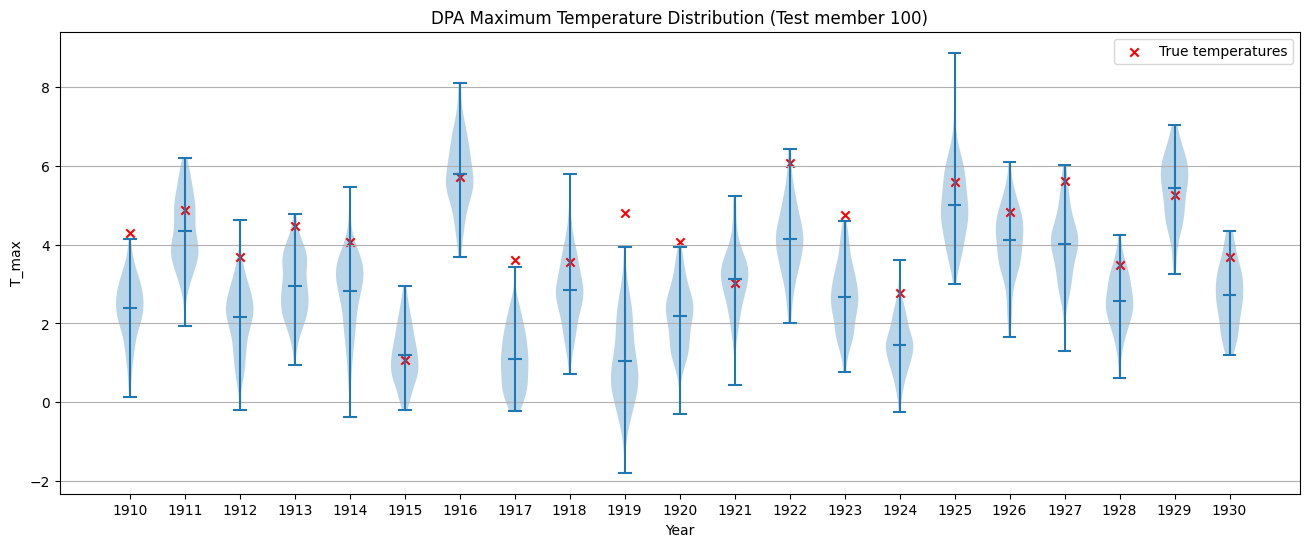

80 101


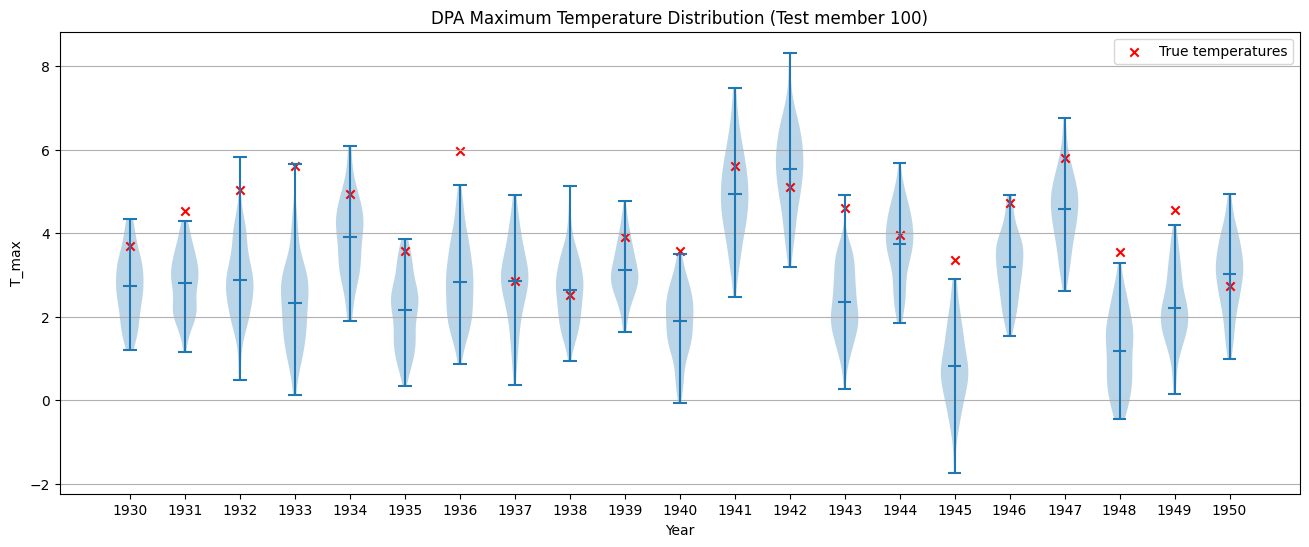

100 121


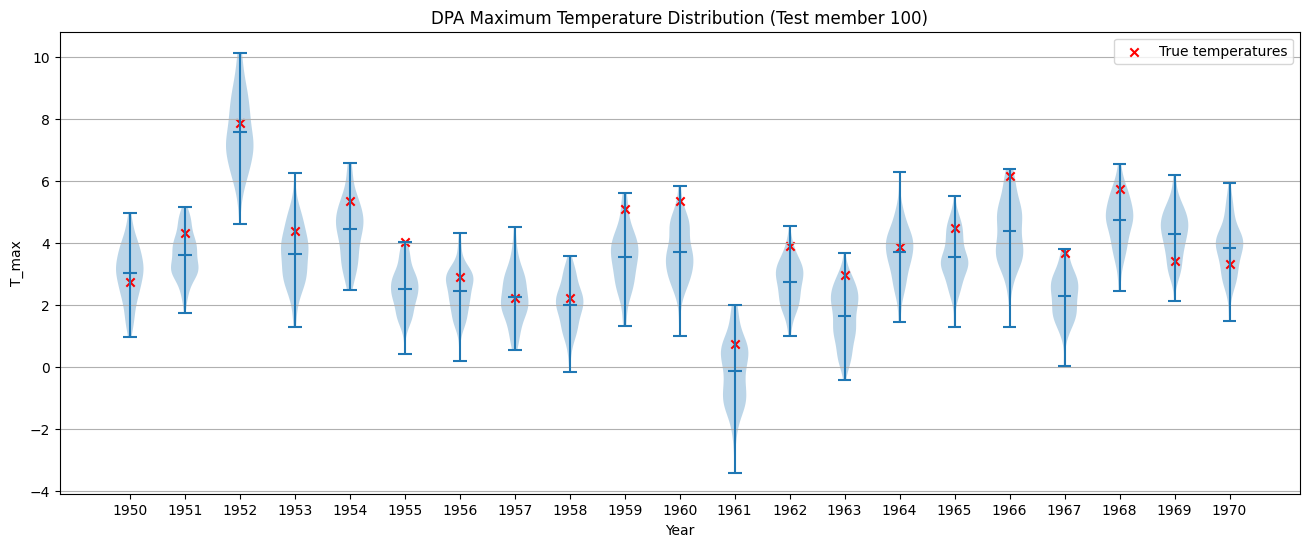

120 141


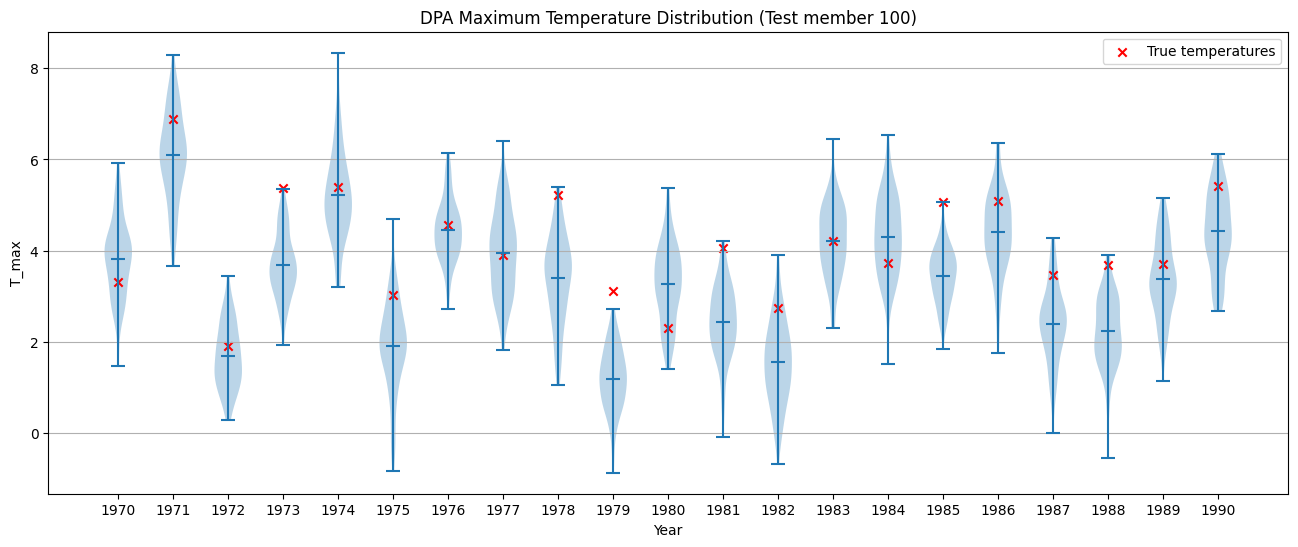

140 161


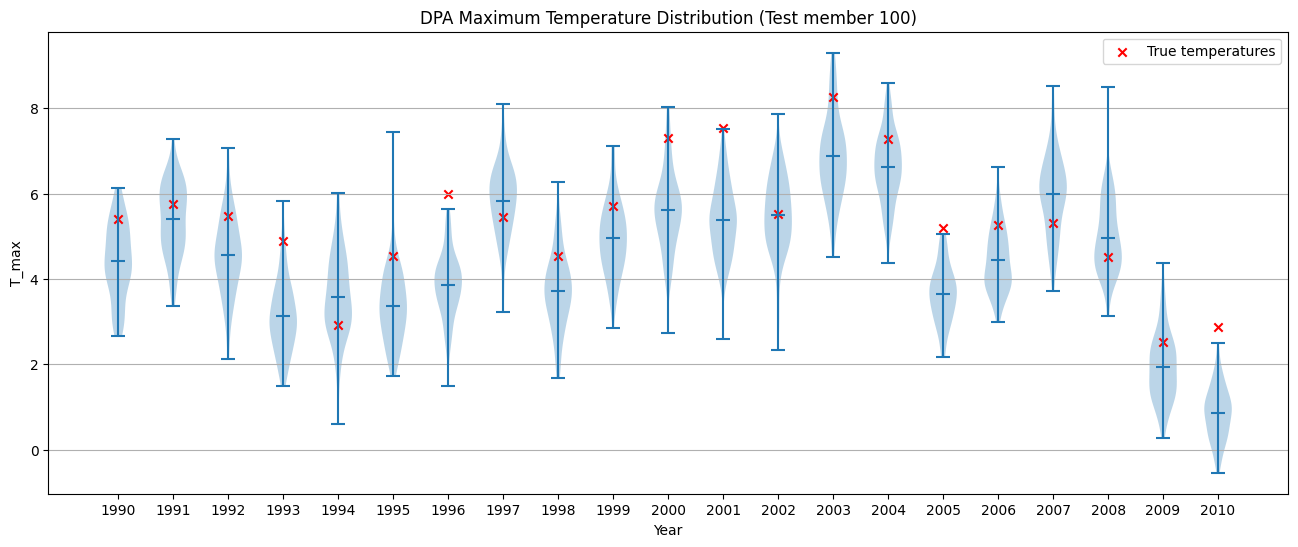

160 181


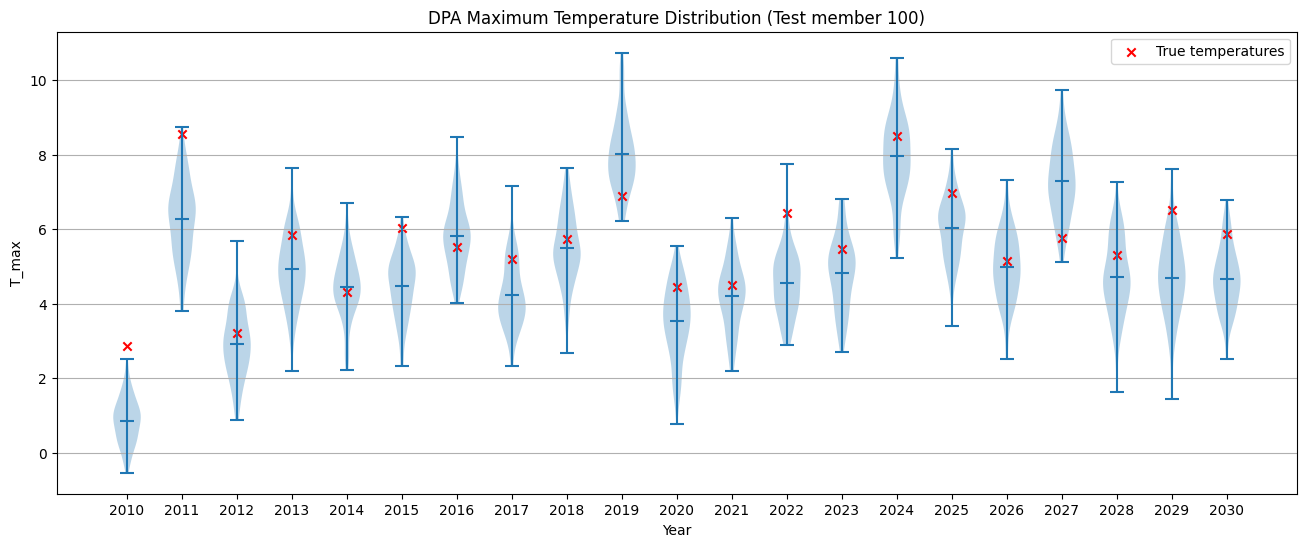

180 201


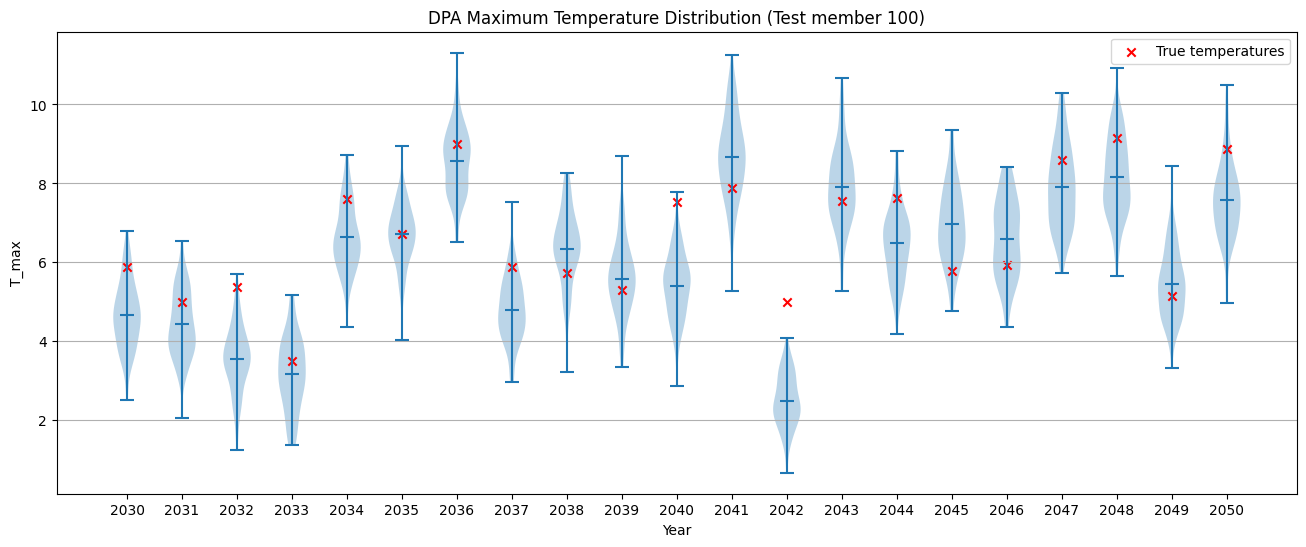

200 221


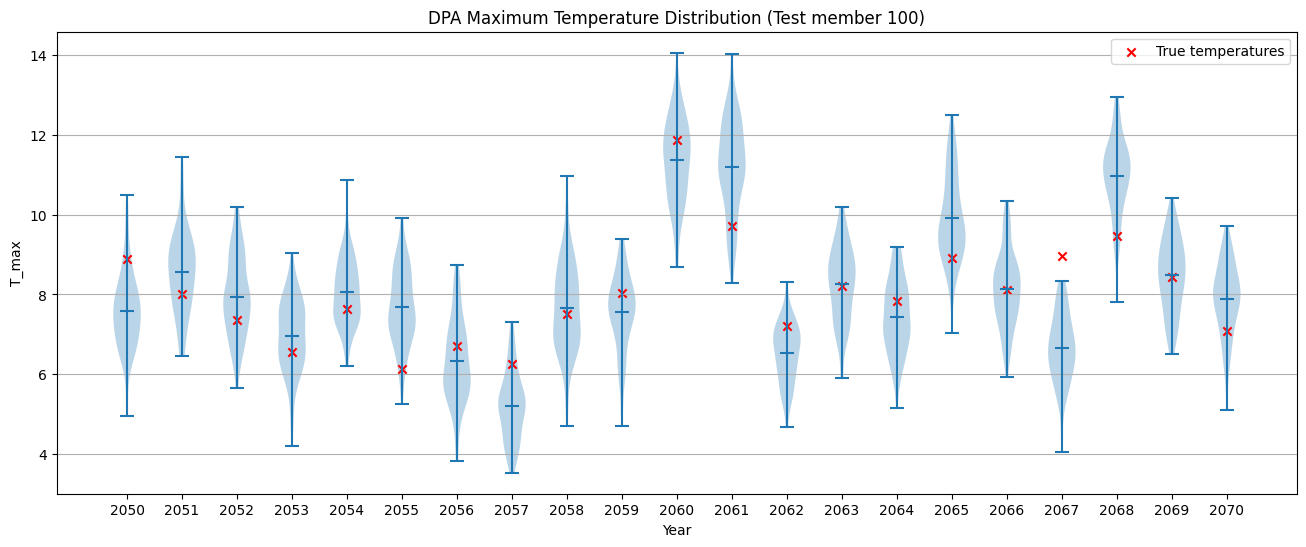

220 241


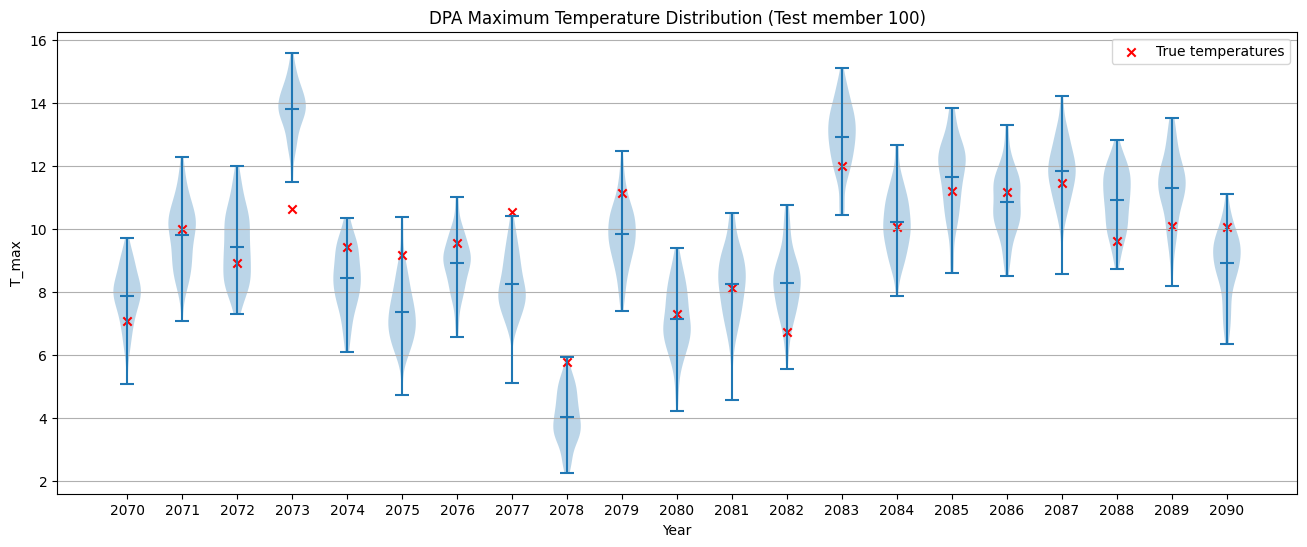

In [93]:
# maximum temperatures

no_violins = 21
years_dist = np.arange(0,240,20)
n = 0
for period in years_dist:
    print(period, period + no_violins)
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
    # plot violin plot
    axs.violinplot(
        list_dpa_ens_max[period:period + no_violins],         # list of arrays, one array per year 
        showmeans=True,
        showmedians=False,
    )
    axs.scatter(range(1,no_violins+1), list_temp_true_max[period:period + no_violins], label="True temperatures", marker="x", color = "red")
    #axs.scatter(range(1,no_violins+1), list_temp_true_min[period:period + no_violins], label="True temperatures", marker="x", color = "blue")

    # axs.scatter(range(1,no_violins+1), list_temp_true_max[n * period:n*period + no_violins], label="True temperatures", marker="x")
    axs.set_title('DPA Maximum Temperature Distribution (Test member 100)')
    
    
    axs.yaxis.grid(True)
    
    axs.set_xticks(range(1,252,1)[:no_violins])  
    axs.set_xticklabels(years[period:period + no_violins])
    
    axs.set_xlabel('Year')
    axs.set_ylabel('T_max')
    plt.legend()
    #plt.savefig(f"figures/max_temps/dpa_max_temp_distr{period}-{period + no_violins}.pdf")
    plt.show()
    n+=1

0 21


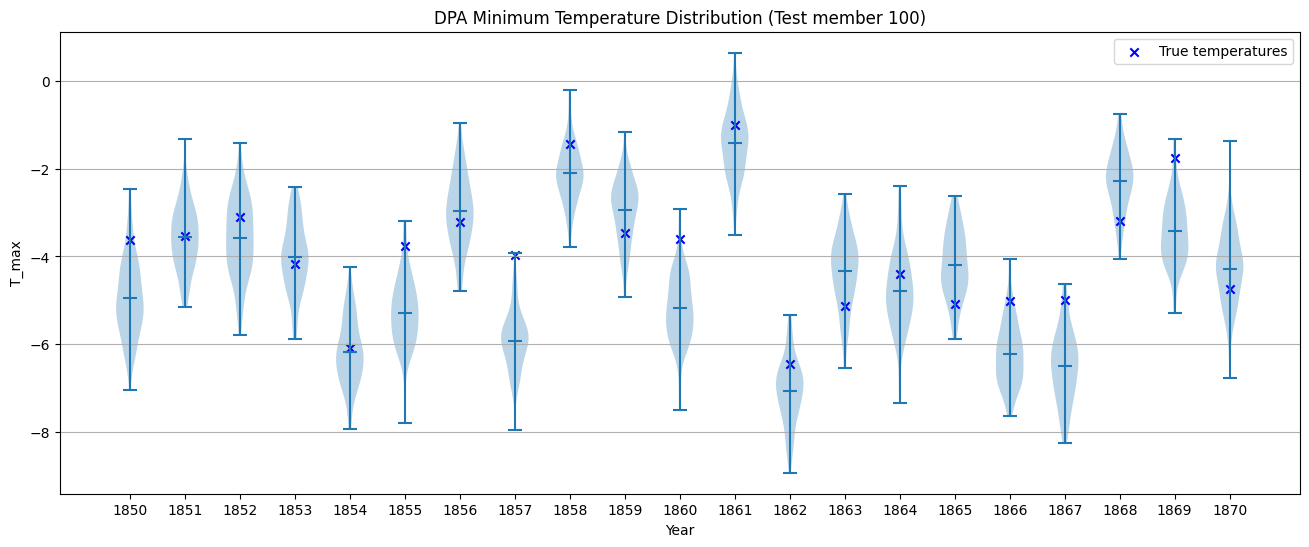

20 41


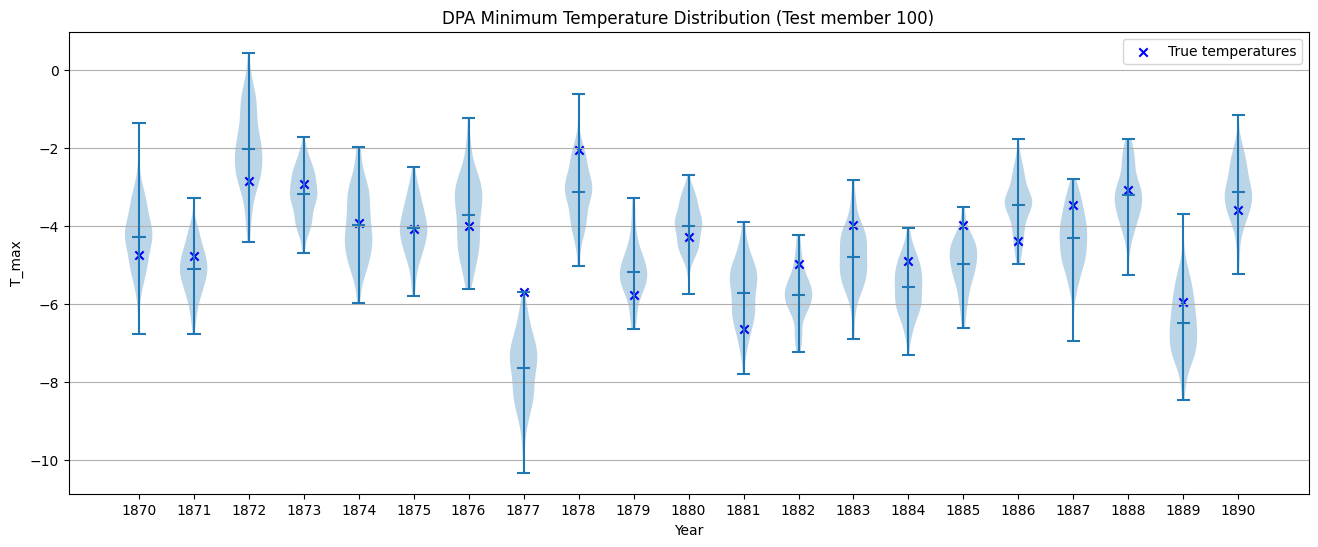

40 61


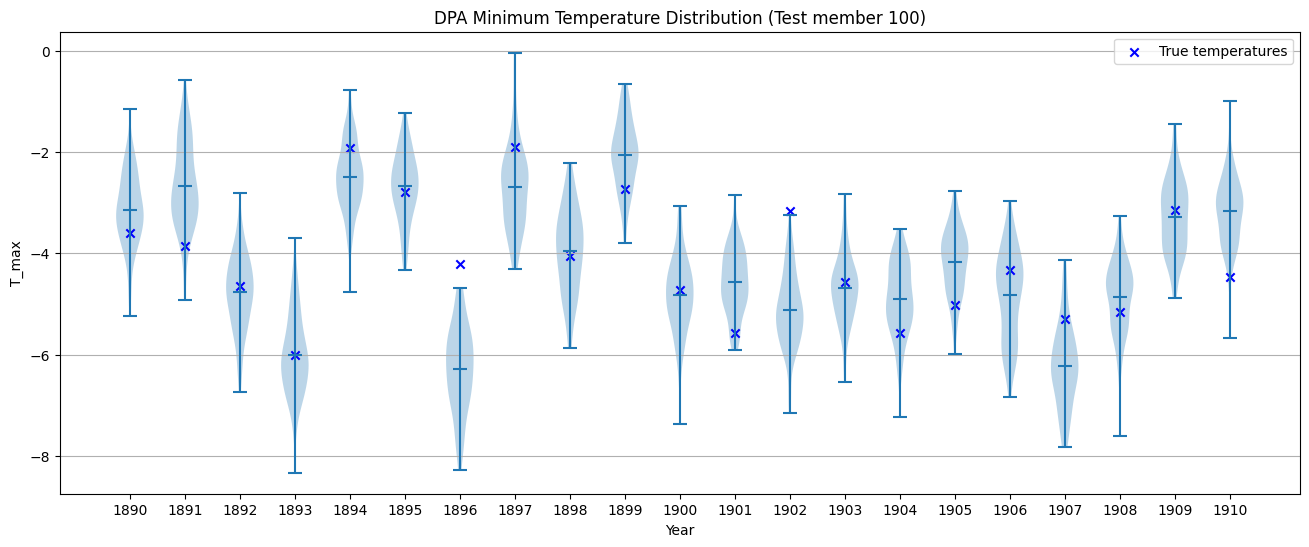

60 81


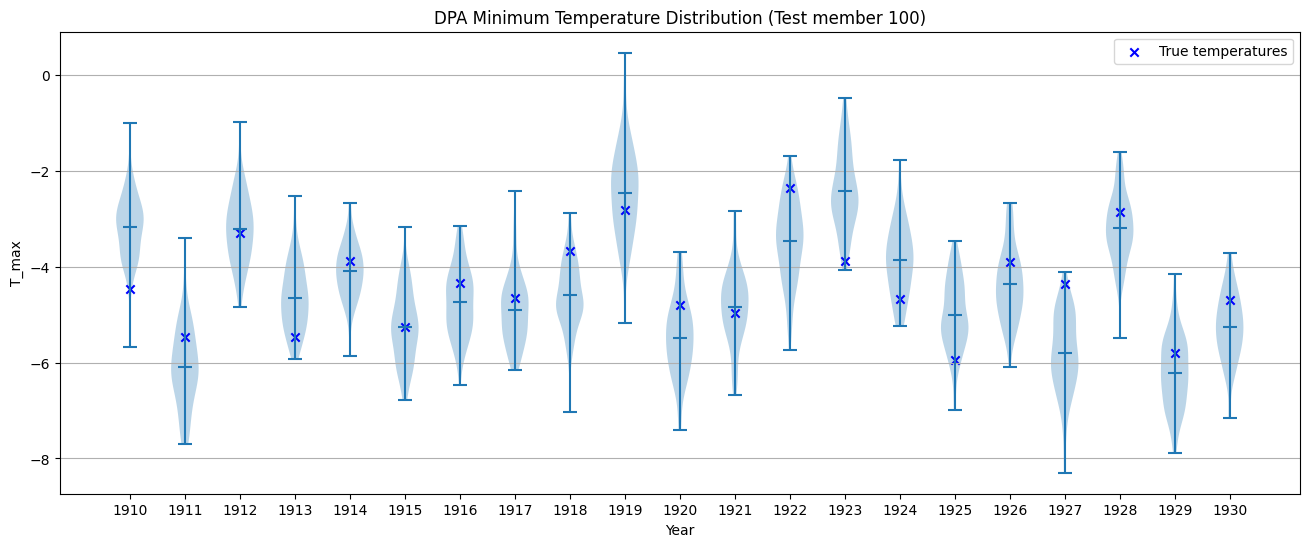

80 101


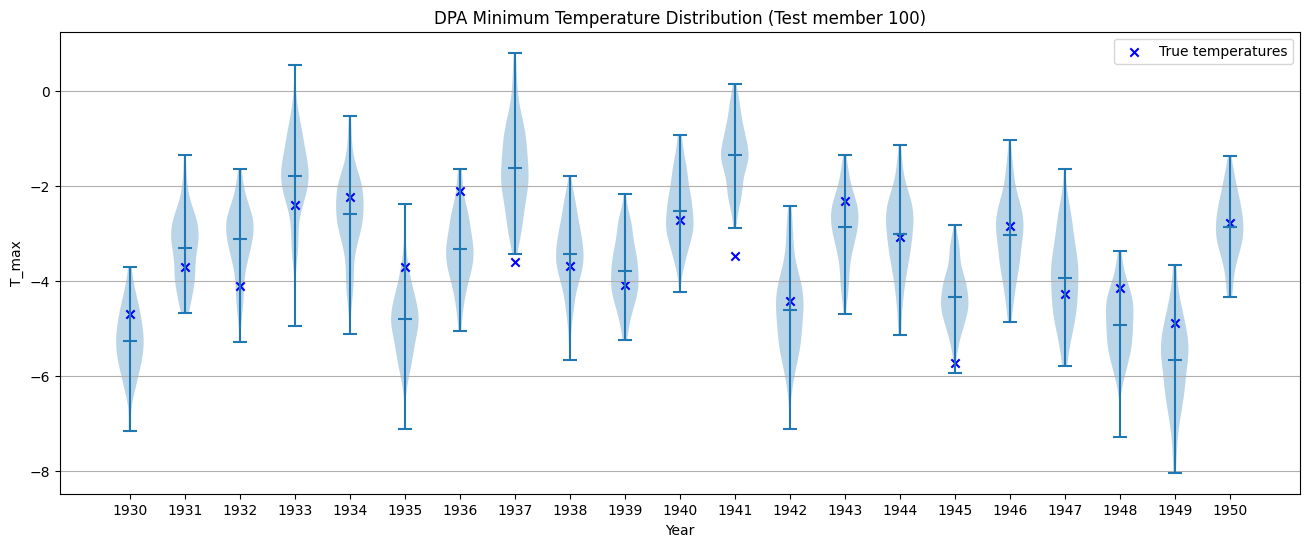

100 121


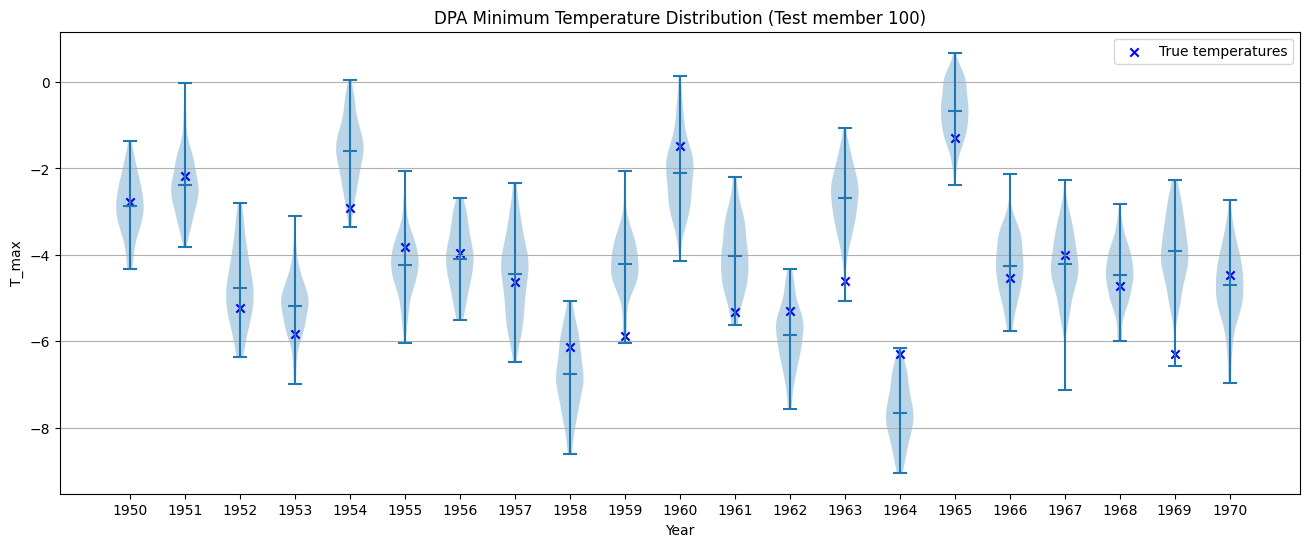

120 141


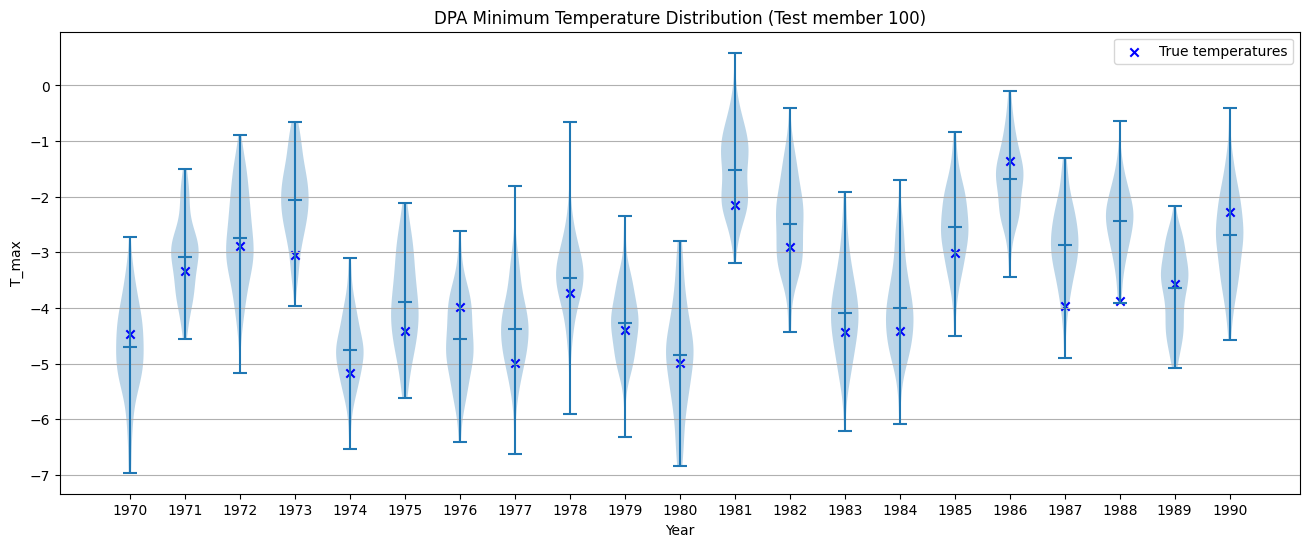

140 161


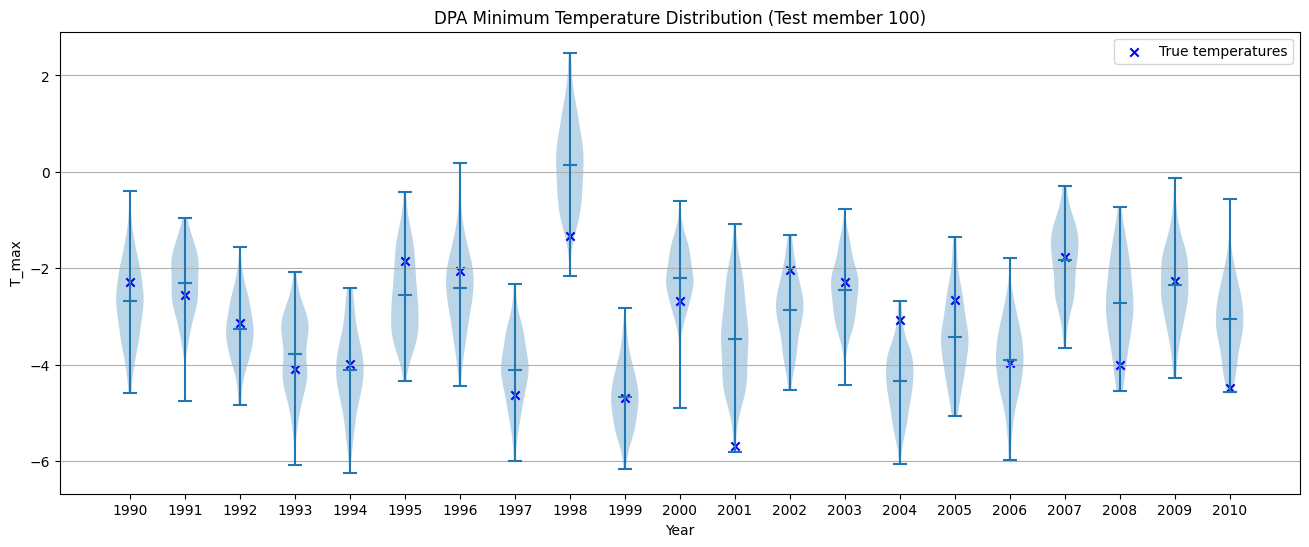

160 181


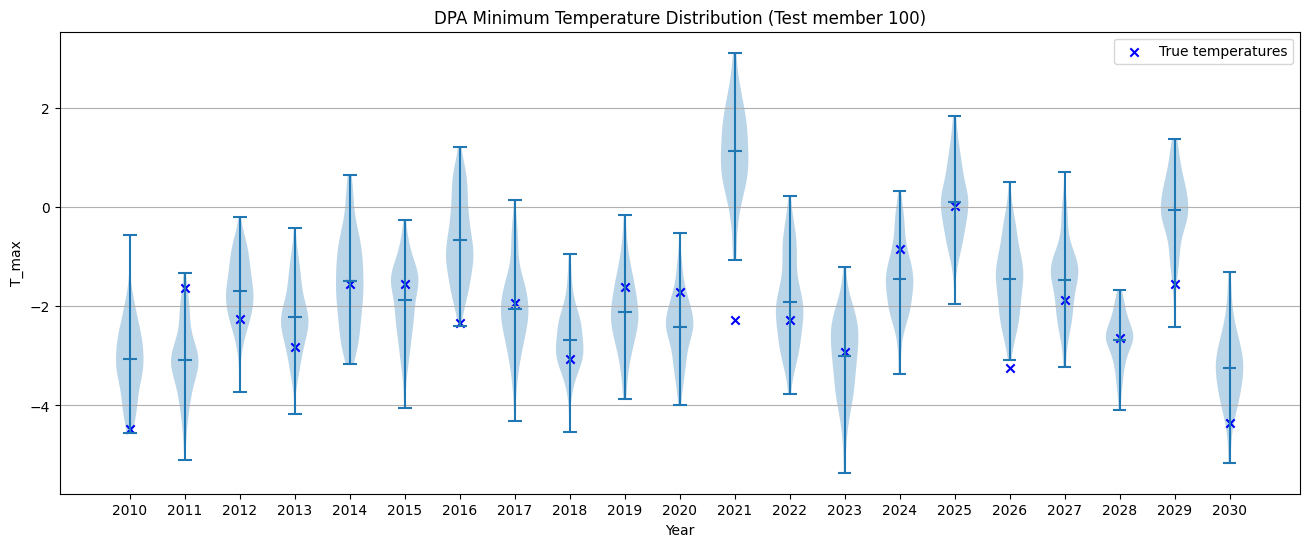

180 201


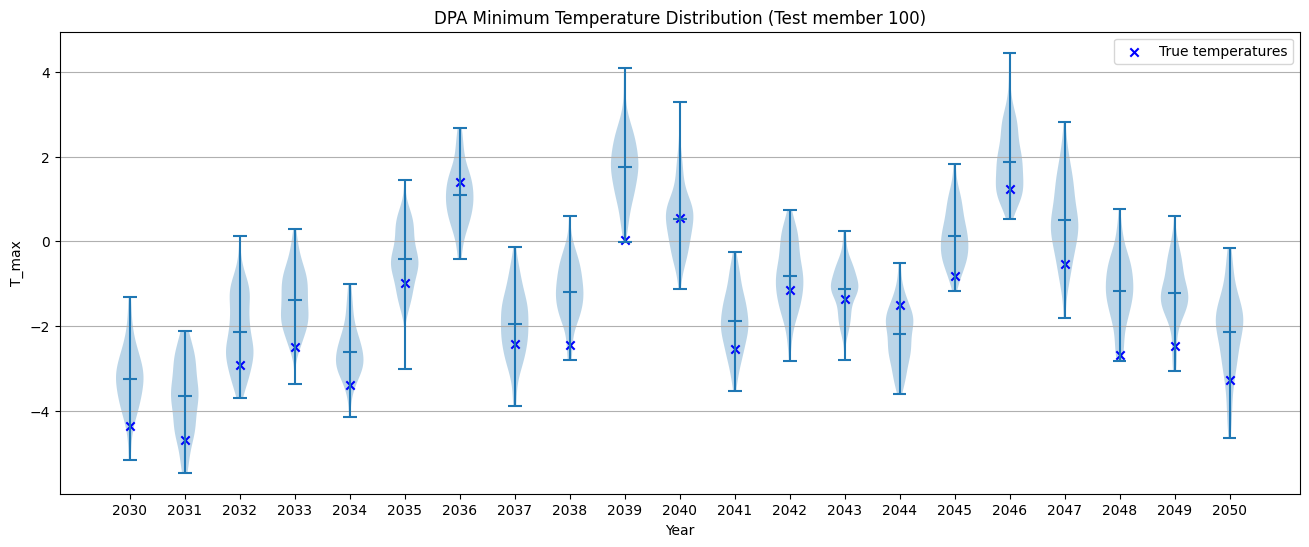

200 221


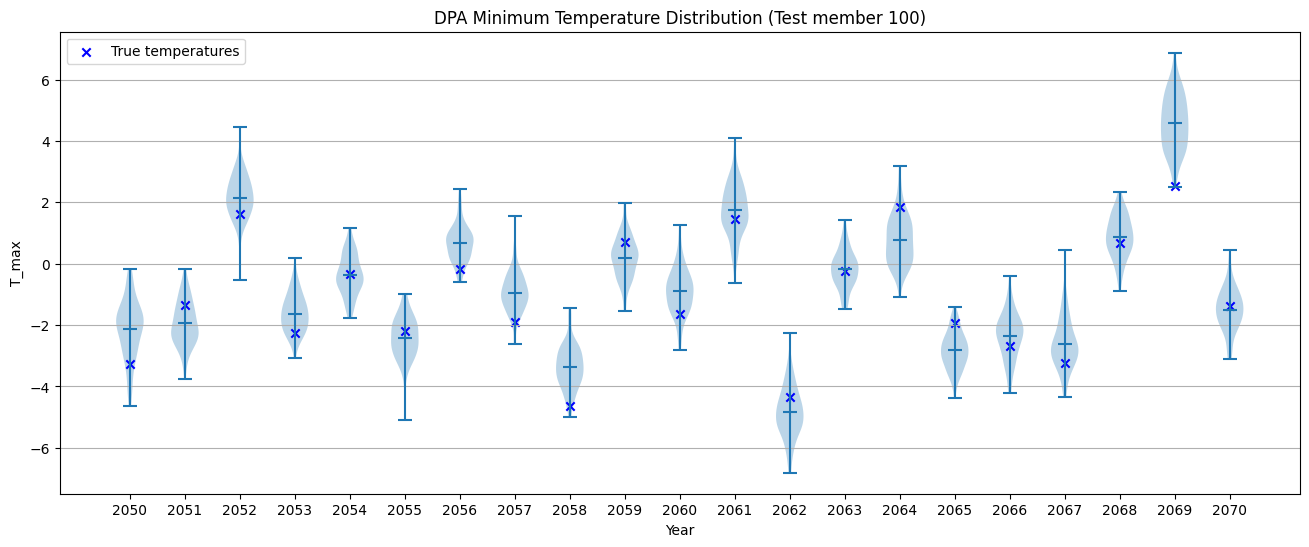

220 241


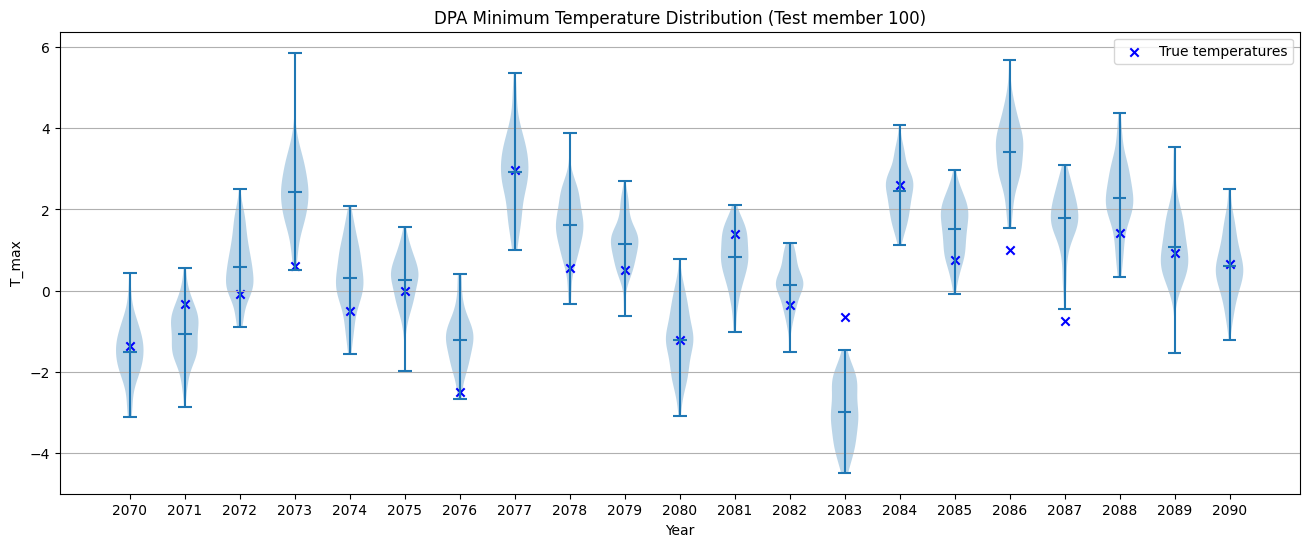

In [95]:
# maximum temperatures

no_violins = 21
years_dist = np.arange(0,240,20)
n = 0
for period in years_dist:
    print(period, period + no_violins)
    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
    # plot violin plot
    axs.violinplot(
        list_dpa_ens_min[period:period + no_violins],         # list of arrays, one array per year 
        showmeans=True,
        showmedians=False,
    )
    axs.scatter(range(1,no_violins+1), list_temp_true_min[period:period + no_violins], label="True temperatures", marker="x", color = "blue")
    #axs.scatter(range(1,no_violins+1), list_temp_true_min[period:period + no_violins], label="True temperatures", marker="x", color = "blue")

    # axs.scatter(range(1,no_violins+1), list_temp_true_max[n * period:n*period + no_violins], label="True temperatures", marker="x")
    axs.set_title('DPA Minimum Temperature Distribution (Test member 100)')
    
    
    axs.yaxis.grid(True)
    
    axs.set_xticks(range(1,252,1)[:no_violins])  
    axs.set_xticklabels(years[period:period + no_violins])
    
    axs.set_xlabel('Year')
    axs.set_ylabel('T_max')
    plt.legend()
    #plt.savefig(f"figures/min_temps/dpa_max_temp_distr{period}-{period + no_violins}.pdf")
    plt.show()
    n+=1

In [51]:
# plot standard deviation over time

array([[3.19251562],
       [4.29945349],
       [4.66674191],
       [3.51439991],
       [4.2211816 ],
       [3.43273268],
       [2.69663342],
       [4.08460742],
       [5.29309416],
       [2.91808221],
       [4.0515787 ],
       [3.72923045],
       [2.70720853],
       [2.58117847],
       [3.29953583],
       [3.06316272],
       [3.21732833],
       [2.91846579],
       [4.41732302],
       [1.41915244],
       [2.21247025],
       [3.8472797 ],
       [3.64269181],
       [3.45729069],
       [3.79398736],
       [3.26439907],
       [2.22457037],
       [3.24879509],
       [2.51197729],
       [3.65737572],
       [3.55684197],
       [3.55620371],
       [2.94302067],
       [4.06652382],
       [4.39782086],
       [2.65389827],
       [2.80206184],
       [2.73975001],
       [5.17928986],
       [2.4047946 ],
       [2.86973651],
       [2.589521  ],
       [2.62232178],
       [3.08168447],
       [2.57189965],
       [3.51383662],
       [4.77906526],
       [2.590